<img src="./logo_UTN.svg" align="right" width="150" /> 

### Teoría de Circuitos II

# Trabajo Semanal N°4

Autor: *Olea Gasalla Ignacio Ezequiel*

*Fecha de entrega: sábado 20 de junio de 2026*

#### **Consigna** 
[👉 Obtener la plantilla de atenuación normalizada en frecuencia.  Indicar los valores de $\alpha_{max}$ y de $\alpha_{min}$ ](#pan) 

[👉 Obtener la función transferencia normalizada del prototipo pasa bajo que satisfaga el requerimiento del filtro pasa banda. ](#tpb) 

[👉 Aplicar el núcleo de transformación pasa banda y obtener la transferencia. Factorizar convenientemente para expresar en SOS. ](#npb) 

[👉 Realizar la simulación numérica en python. Graficar la respuesta en frecuencia del filtro pasa banda total, y las de las SOS.  ](#grf)

##### **Bonus**:
[💎 Simulación Circuital del filtro pasa banda implementado mediante secciones pasivas separadas por seguidores de tensión activos. ](#src) 

[💎 Dado el pasa bajo hallado en 2)  aplicar el núcleo de transformación pasa altos y obtener la transferencia.](#npa) 
 
[💎 Dado el pasa bajo hallado en 2) , implementarlo con pasivos y aplicar la transformación de Bruton. Obtener el valor numérico de D del FDNR siendo 
$Z_{FDNR}=\frac{1}{s^2D}$.](#tbt) 

##### **Anexo**:
📎 En caso de no poder acceder al documento, presione aquí: [Mostrar PDF](./tc2_ts4.pdf)

📎 Recordar ejecutar el cuadro siguiente de librerias:

In [3]:
# Importo las librerias
import math
import sympy as sp
import numpy as np
import scipy.signal as sig
from sympy import Eq
from IPython.display import display, IFrame, Math
from matplotlib import pyplot as plt
from scipy.signal import TransferFunction

from pytc2.sistemas_lineales import pretty_print_lti, tfcascade, pzmap, GroupDelay, bodePlot, pretty_print_SOS, tf2sos_analog, pretty_print_bicuad_omegayq,tf2zpk, parametrize_sos, analyze_sys
from pytc2.general import s, w, print_latex, a_equal_b_latex_s, print_subtitle, Chebyshev_polynomials

# Función para mostrar en formato de ingenieria las unidades
def eng_format(value, unit=""):
    import numpy as np
    if value == 0:
        return f"0 {unit}"
    exp = int(np.floor(np.log10(abs(value)) / 3) * 3)
    scaled = value / (10**exp)
    prefixes = {-12: "p",-9: "n",-6: "u",-3: "m",0: "",3: "k",6: "M",9: "G"}
    prefix = prefixes.get(exp, f"e{exp}")
    return f"{scaled:.2f} {prefix}{unit}"

#--------------------------------------------------------------------------

In [24]:
IFrame("./tc2_ts4.pdf", width=1000, height=1000)

<a id="pan"></a>
#### **Obtención de la Plantilla de Atenuación Normalizada**

En el documento superior se muestra la obtención de la plantilla de atenuación Pasa Banda, con: 
\begin{equation}
\begin{cases} 
    Q = 5
        \\\\
    B = 0.2 \frac{'rad'}{s}
\end{cases}
    \\\\
\begin{cases} 
    \alpha_{max} = 0.5 dB
        \\\\
    \alpha_{min1} = 16 dB
        \\\\
    \alpha_{min2} = 24 dB
\end{cases}
    \\\\
\begin{cases} 
    \omega_{0}  = 1.00 \frac{'rad'}{s}
        \\\\
    \omega_{1}  = 0.90 \frac{'rad'}{s}
        \\\\
    \omega_{2}  = 1.10 \frac{'rad'}{s}
        \\\\
    \omega_{s1} = 0.77 \frac{'rad'}{s}
        \\\\
    \omega_{s2} = 1.63 \frac{'rad'}{s}
\end{cases}
\end{equation}

<a id="tpb"></a>
#### **Obtención de la Trasferencia Pasa Bajos**

En el documento superior se obtiene la plantilla de atenuación para un filtro Pasa Bajos normalizado, teniendo como caracteristicas:
\begin{equation}
\begin{cases} 
    n  = 3
        \\\\
    \Omega_{p}  = 1 \frac{'rad'}{s}
        \\\\
    \Omega_{s}  = 2.64 \frac{'rad'}{s}
        \\\\
    \alpha_{max} = 0.5 dB
        \\\\
    \alpha_{min} = 16 dB
\end{cases}
\end{equation}
En el cuadro de código siguiente se obtiene el valor de la transferencia Pasa Bajos:


Función transferencia al cuadrado de Cheby:


Eq(|T_{Cheby}|^2(s), 0.965529023465404/(1.0*s**4 + 1.0*s**2 + 1.2155290234654))


Función transferencia usada para el gráfico:


<IPython.core.display.Math object>


o expresada en SOS:


<IPython.core.display.Math object>


Frecuencia: 0 Hz
Módulo (dB) = -1.000 dB

Frecuencia: 0.15915494309189535 Hz
Módulo (dB) = -1.000 dB


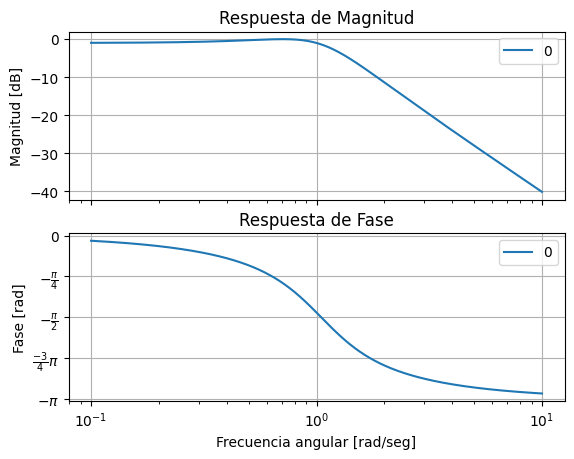

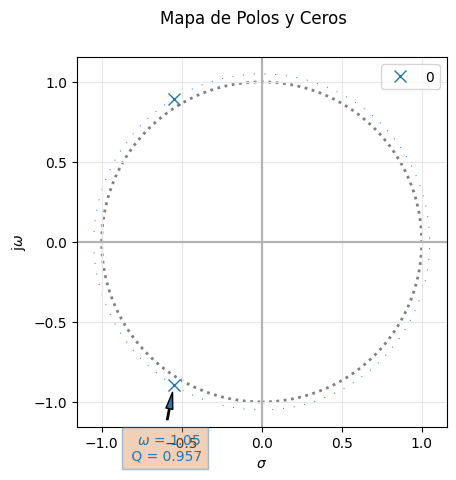

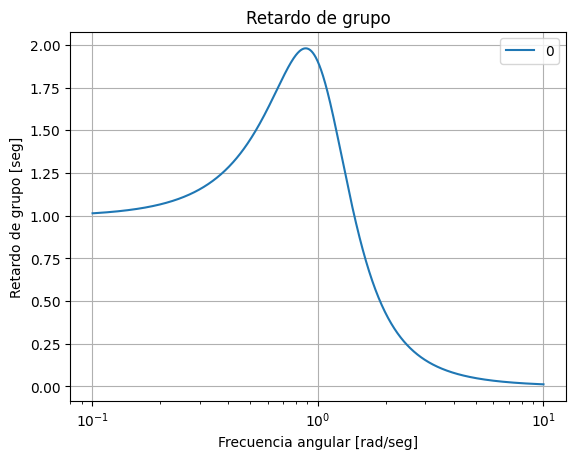

In [7]:
# Elijo el orden y ripple que necesito:
order  = 2
ripple = 1 # \alpha_{max}

# Calculo el epsilon:
eps = np.sqrt( 10**(ripple/10) - 1 )

# Calculo el módulo de la Transferencia al cuadrado en función de 's' de un Chebyshev:
T = sp.expand(1 + eps**2 * (sp.expand(Chebyshev_polynomials(order)))**2)
w_ = list(T.free_symbols)[0] # Permite que .subs funcione 
T = T.subs(w_, s/sp.I)

# Dejo mónico el polinomio:
T_poly = sp.Poly(T, s)
cp = T_poly.LC()
T = (1/cp) / (T/cp)

print('\n'rf"Función transferencia al cuadrado de Cheby:")
display(Eq(sp.Function("|T_{Cheby}|^2")(s), T))

#----------------------------------------------------------------------------------------------------------------------

# Asigno los valores del módulo de la transferencia al cuadrado:
num = 0.965529023465404
den = np.array([ 1 , 0 , 1 , 0 , 1.215529 ])

# Calculo sus polos y me quedo solo con los que están en el lado izquierdo del eje jw del plano Laplace:
cheby_roots = np.roots(den)
cheby_roots = cheby_roots[ np.real(cheby_roots) < 0 ]

# Consigo el numerador y denominador de la transferencia:
z = []
p = cheby_roots
k = np.sqrt(np.abs(num))
num, den = sig.zpk2tf(z,p,k)

# Muestro y grafico la transferencia Pasa Bajos conseguida:
print('\n'rf"Función transferencia usada para el gráfico:")
pretty_print_lti(num,den)
print('\n'rf"o expresada en SOS:")
mi_tf_lp = sig.TransferFunction(num,den)
analyze_sys( mi_tf_lp )
this_sos = tf2sos_analog(num, den)
pretty_print_SOS(this_sos, mode='omegayq')

#------------------------------------------------------------------------------
# Frecuencias en Hz
f1 = 0
f2 = 1/(2*np.pi)

# Convertir a rad/s
w1 = 2*np.pi*f1
w2 = 2*np.pi*f2

# Evaluar respuesta en frecuencia
w_eval, H_eval = sig.freqresp(mi_tf_lp, [w1, w2])

# Mostrar resultados
for f, H in zip([f1, f2], H_eval):
    modulo_db = 20*np.log10(abs(H))

    print(f"\nFrecuencia: {f} Hz")
    print(f"Módulo (dB) = {modulo_db:.3f} dB")

<a id="npb"></a>
#### **Obtención de la Trasferencia Pasa Banda Aplicando el Núcleo de la Transformación**
En el siguiente código se utiliza la transferencia LP anterior y se le aplica la transformación $s=\frac{s^2+1}{s}$ para llevar la transferencia a un Pasa Banda:


Función transferencia:


Eq(T(s), 7.43*s**2/(1.0*s**4 + 3.02*s**3 + 10.3*s**2 + 3.02*s + 1.0))


Función transferencia usada para el gráfico:


<IPython.core.display.Math object>


o expresada en SOS:


<IPython.core.display.Math object>


Frecuencia: 0.1193662073189215 Hz
Módulo (dB) = -0.847 dB

Frecuencia: 0.5570423008216338 Hz
Módulo (dB) = -2.501 dB

Frecuencia: 0.15915494309189535 Hz
Módulo (dB) = -1.004 dB


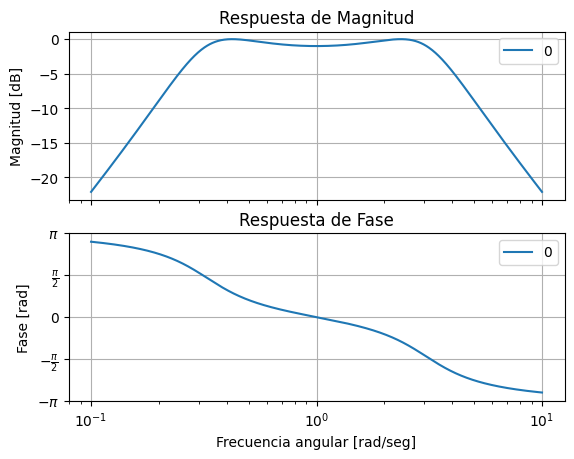

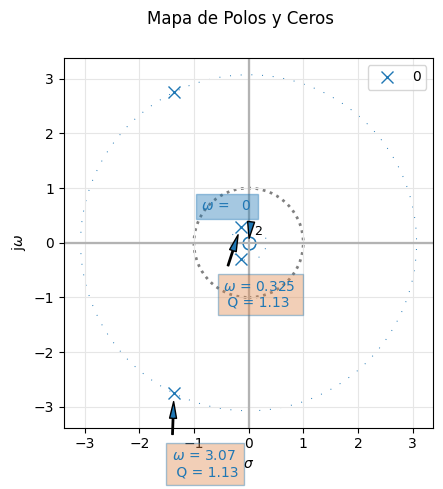

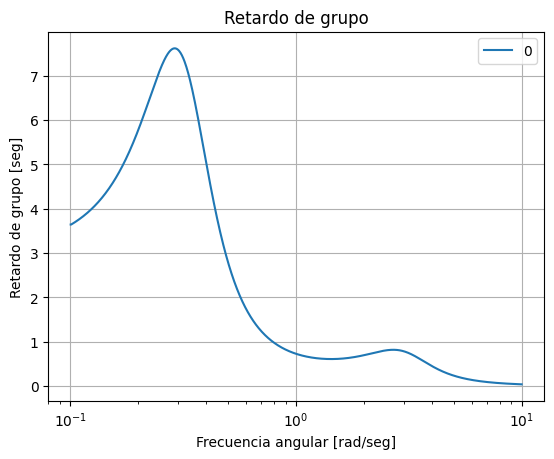

In [18]:
# Asigno los valores del módulo de la transferencia al cuadrado (conseguida en el cuadro de codigo anterior):
num = 0.965529023465404
den = np.array([ 1 , 0 , 1 , 0 , 1.215529 ])
Q = 0.3636

# Calculo sus polos y me quedo solo con los que están en el lado izquierdo del eje jw del plano Laplace:
cheby_roots = np.roots(den)
cheby_roots = cheby_roots[ np.real(cheby_roots) < 0 ]

# Consigo el numerador y denominador de la transferencia:
z = []
p = cheby_roots
k = np.sqrt(np.abs(num))
num, den = sig.zpk2tf(z,p,k)

# Reemplazo 's' por la función transformación de LP->BP:
s = sp.symbols('s')

num = sp.Poly(num, s).as_expr()
den = sp.Poly(den, s).as_expr()
H = num/den

H = H.subs({ s:(Q*((s**2+1)/(s))) })

# Dejo mónico la transferencia:
num, den = H.as_numer_denom()
coef = sp.Poly(den, s).all_coeffs()[0]
H = sp.simplify((num/coef) / (den/coef)).evalf(3)

print('\n'rf"Función transferencia:")
display(Eq(sp.Function('T')(s), H))

# Asigno los valores de la transferencia Pasa Banda recien obtenida:
num = np.array([ (7.43) , 0 , 0 ])
den = np.array([ 1 , 3.02 , 10.34 , 3.02 , 1 ])

# Muestro y grafico la transferencia Pasa Banda conseguida:
print('\n'rf"Función transferencia usada para el gráfico:")
pretty_print_lti(num,den)
print('\n'rf"o expresada en SOS:")
mi_tf_lp = sig.TransferFunction(num,den)
analyze_sys( mi_tf_lp )
this_sos = tf2sos_analog(num, den)
pretty_print_SOS(this_sos, mode='omegayq')

#------------------------------------------------------------------------------
# Frecuencias en Hz
f1 = 0.75/(2*np.pi)
f2 = 3.5/(2*np.pi)
f3 = 1/(2*np.pi)

# Convertir a rad/s
w1 = 2*np.pi*f1
w2 = 2*np.pi*f2
w3 = 2*np.pi*f3

# Evaluar respuesta en frecuencia
w_eval, H_eval = sig.freqresp(mi_tf_lp, [w1, w2, w3])

# Mostrar resultados
for f, H in zip([f1, f2, f3], H_eval):
    modulo_db = 20*np.log10(abs(H))

    print(f"\nFrecuencia: {f} Hz")
    print(f"Módulo (dB) = {modulo_db:.3f} dB")

<a id="grf"></a>
#### **Gráfico de la Respuesta del Filtro**
En el item anterior se gráfico el BP total. En el cuadro de código siguiente se gráficara las SOS individualmente:


Frecuencia: 39788.735772973836 Hz
Módulo (dB) = 23.312 dB

Frecuencia: 1 Hz
Módulo (dB) = 0.000 dB


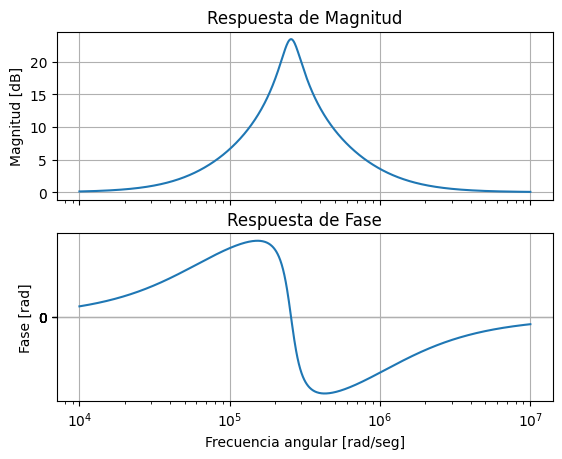

In [5]:
# Ingreso los valores de K, Q y omega_0:
Q      = 5
w0     = 2*np.pi*40e3

num1 = [ 1 , 1.06e6 , (255.83e3)**2 ]
den1 = [ 1 , 71.43e3, (255.83e3)**2 ]

num2 = [ 0 , 0 , 1 ]
den2 = [ 1 , 71.43e3, (255.83e3)**2 ]

# Formo un vector con los numeradores y denominadores de las distintas transferencias:
num   = [ num1, num2]
den   = [ den1, num3]

tf_tot = []

# Se grafica las transferencias obtenidas:
#print('\n'rf"Funciones transferencia usadas para el gráfico:")
for i, (num_, den_) in enumerate(zip(num, den)):
    '''
    this_sos = tf2sos_analog(num_, den_)
    pretty_print_SOS(this_sos, mode='omegayq')
    '''
    # Pongo en cascada las tres transferencias SOS para conseguir la Transferencia total:
    mi_tf = sig.TransferFunction(num_,den_)
    tf_tot.append(mi_tf)
    if len(tf_tot) != 1:
        tf_tot[i] = tfcascade(tf_tot[i-1], tf_tot[i])
    
    #bodePlot( mi_tf ,  fig_id=1 )
    
bodePlot( tf_tot[0] , fig_id=2 )

#--------------------------------------------------------------------------------------------

# Frecuencias en Hz
f1 = 2.5e5/(2*np.pi)
f2 = 1

# Convertir a rad/s
w1 = 2*np.pi*f1
w2 = 2*np.pi*f2

# Evaluar respuesta en frecuencia
w_eval, H_eval = sig.freqresp(tf_tot[-1], [w1, w2])

# Mostrar resultados
for f, H in zip([f1, f2], H_eval):
    modulo_db = 20*np.log10(abs(H))

    print(f"\nFrecuencia: {f} Hz")
    print(f"Módulo (dB) = {modulo_db:.3f} dB")

<a id="src"></a>
#### **Simulación de la red circuital**

In [11]:
# SOS = [ C1 , K1 , Q1 , w01 , C2 , K2 , Q2 , w02 , C3 , K3 , Q3 , w03 ]
C = 0
K = 1
Q = 2
w0 = 3

# --------------------------------------------------------------------
SOS_1 = [ 100e-6 , 0.9583 , 8.883 , 1      ]
SOS_2 = [ 100e-6 , 1.834  , 14.52 , 0.9054 ]
SOS_3 = [ 100e-6 , 4.369  , 14.52 , 1.105  ]

SOS = [ SOS_1 , SOS_2 , SOS_3 ]

for i in range(len(SOS)):
    L  = 1 / ( SOS[i][w0]**2 * SOS[i][C] )
    R  = 1 / ( SOS[i][Q] * SOS[i][w0] * SOS[i][C] )
    
    print('\n'rf"Los valores para una SOS son:")
    print(rf"   K = {eng_format(SOS[i][K], 'V/V')} ")
    print(rf"   C = {eng_format(SOS[i][C], 'F')} ")
    print(rf"   L = {eng_format(L , 'H')} ")
    print(rf"   R = {eng_format(R , 'Ω')} ")


Los valores para una SOS son:
   K = 958.30 mV/V 
   C = 100.00 uF 
   L = 10.00 kH 
   R = 1.13 kΩ 

Los valores para una SOS son:
   K = 1.83 V/V 
   C = 100.00 uF 
   L = 12.20 kH 
   R = 760.66 Ω 

Los valores para una SOS son:
   K = 4.37 V/V 
   C = 100.00 uF 
   L = 8.19 kH 
   R = 623.26 Ω 


<img src="./circuit_1.png" /> 

En el circuito de arriba se pusieron en cascada los tres Pasa Banda pasivos de las SOS, referidos como etapas separadas por un buffer.:

-La primera etapa debe tener una ganancia de $ K = 958.30 mV/V $ por lo que se usó un divisor de impedancia en la ultima resistencia para lograr esa atenuación.

-La segunda etapa debe tener una ganancia de $ K = 1.83 V/V $. Ya que hay dificultad en conseguir ganancia con un circuito pasivo, luego del pasa banda se implemento una subetapa con un amplificador no inversor de la ganancia deseada. Hacer esto directamente se debe a que el operación el ideal debido a que ni si quiera los offsets están compensados.

-En la tercera y ultima etapa se requeria una ganancia de $ K = 4.37 V/V $ y se utilizó el método anterior para conseguirla.

NOTA:
Poner una etapa amplificadora de la forma que se colocó no solo es ineficiente (por cuestiones financieras) si no que tambien no se podría implementar directamente ya que en la simulación son operacionales ideales y habría que hacer varias modificaciones para que no haya inconvenientes.
Se dejó completamente de lado lo que respecta a la fase de la transferencia debido a que no era directamente de interés. Por este motivo se omitió el signo negativo que posee la primera SOS pero se podría conseguir poniendo un Amp. Inversor como otra subetapa más en la cascada.

<img src="./plot_circuit_1.png" /> 

Se graficarón las transferencias de las distintas etapas (con la inclusión de la amplificación) y luego la transferencia total resultante de la cascada:

-El gráfico amarillo corresponde a la primera etapa.

-El gráfico azul     corresponde a la segunda etapa.

-El gráfico rojo     corresponde a la tercera etapa.

-El gráfico rosa     corresponde a la transferencia total.

<a id="npa"></a>
#### **Núcleo Transformado Pasa Altos**
La obtención de la transferencia desde el prototipo Pasa Bajos se resuelve en la siguiente linea de código (se usó un nucleó transformado $\Omega=1/s$ tal que $\omega_0=1 \frac{'rad}{s}$ visto con anterioridad en materias pasadas):


Función transferencia:


Eq(T(s), -1.0*s**3/(1.0*s**3 + 2.14*s**2 + 1.75*s + 1.4))


Función transferencia usada para el gráfico:


<IPython.core.display.Math object>


o expresada en SOS:


<IPython.core.display.Math object>

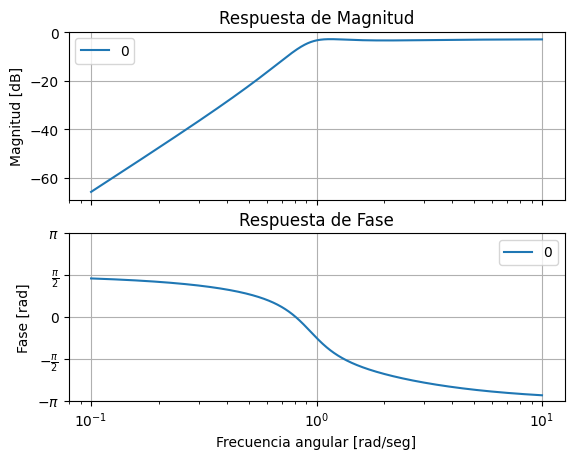

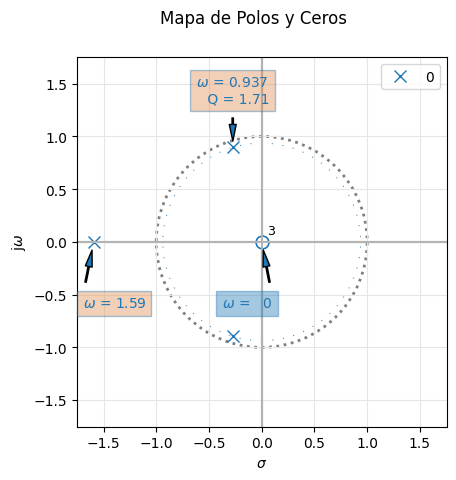

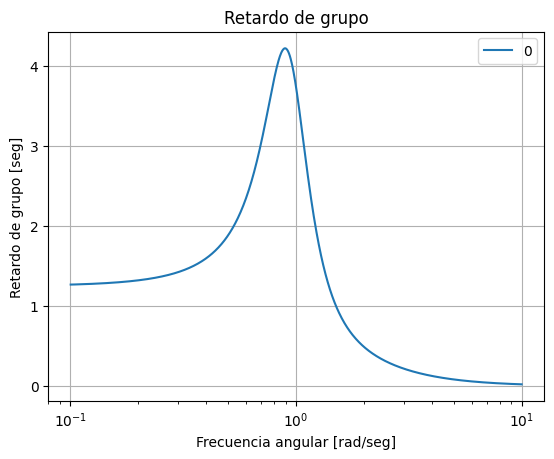

In [28]:
# Asigno los valores del módulo de la transferencia al cuadrado (conseguida en un cuadro de codigo anterior):
num = -0.512217601489436
den = np.array([ 1 , 0 , 1.5 , 0 , 0.5625 , 0 , -0.512217601489436 ])

# Calculo sus polos y me quedo solo con los que están en el lado izquierdo del eje jw del plano Laplace:
cheby_roots = np.roots(den)
cheby_roots = cheby_roots[ np.real(cheby_roots) < 0 ]

# Consigo el numerador y denominador de la transferencia:
z = []
p = cheby_roots
k = -np.sqrt(np.abs(num))
num, den = sig.zpk2tf(z,p,k)

# --------------------------------------------------------------------------------------------------------------------------------------------------

# Reemplazo 's' por la función transformación de LP->HP:
s = sp.symbols('s')

num = sp.Poly(num, s).as_expr()
den = sp.Poly(den, s).as_expr()
H = num/den

H = H.subs({ s:(1/s) })

# Dejo mónico la transferencia:
num, den = H.as_numer_denom()
coef = sp.Poly(den, s).all_coeffs()[0]
H = sp.simplify((num/coef) / (den/coef)).evalf(3)

print('\n'rf"Función transferencia:")
display(Eq(sp.Function('T')(s), H))

# Asigno los valores de la transferencia Pasa Altos recien obtenida:
num = np.array([ (-0.716) , 0 , 0 , 0 ])
den = np.array([ 1 , 2.14 , 1.75 , 1.4 ])

# Muestro y grafico la transferencia Pasa Altos conseguida:
print('\n'rf"Función transferencia usada para el gráfico:")
pretty_print_lti(num,den)
print('\n'rf"o expresada en SOS:")
mi_tf_lp = sig.TransferFunction(num,den)
analyze_sys( mi_tf_lp )
this_sos = tf2sos_analog(num, den)
pretty_print_SOS(this_sos, mode='omegayq')

<a id="tbt"></a>
#### **Transformación de Bruton**

In [23]:
# Agregamos los valores de 
C  = 100e-6
K  = 0.716
sg = 0.6265 # Sigma
w0 = 1.069
Q  = 1.706

L  = 1 / ( w0 * C )
R  = 1 / ( Q  * C )
R0 = 1 / (      C )
R1 = 1 / ( sg * C )
    
print('\n'rf"Los valores de los componentes para implementar el Pasa Bajos son:")
print(rf"   a  = {eng_format(K  , 'V/V')} ")
print(rf"   C  = {eng_format(C  , 'F'  )} ")
print(rf"   L  = {eng_format(L  , 'H'  )} ")
print(rf"   R  = {eng_format(R  , 'Ω'  )} ")
print(rf"   R0 = {eng_format(R0 , 'Ω'  )} ")
print(rf"   R1 = {eng_format(R1 , 'Ω'  )} ")


Los valores de los componentes para implementar el Pasa Bajos son:
   a  = 716.00 mV/V 
   C  = 100.00 uF 
   L  = 9.35 kH 
   R  = 5.86 kΩ 
   R0 = 10.00 kΩ 
   R1 = 15.96 kΩ 


Armado del circuito y gráfico:
<img src="./circuit_2.png" /> 

<img src="./plot_circuit_2.png" /> 

De esta forma queda armado y graficado el pasa bajos, se demuestra la ventaja de usar el teorema de Bruton debido a que en el circuito original se pedía una bobina de casi 10kH y al aplicarle la transformación se consiguió valores más realitas. El desarrollo se encuentra en el documento pero a grandes rasgos se implemento dos filtros pasa bajos en cascada (para armar un filtro de 3er orden). La ganancia (atenuación) se la coloqué con el divisor de impedancia en el primer filtro, separé las etapas por un buffer y en el circuito de 2do orden le aplique la transformada de Bruton. Se usaron los valores de los componentes que se calcularon arriba y se impuso un valor de capacitor de 100uF en todo lo que se pudo.

In [6]:
# Declaro qué es variable, componente y tensiones.
s = sp.symbols('s')
R, L, C, C1, R2, C3, R4, R5 = sp.symbols('R L C R1 C2 R3 R4 R5')
V1, V2, Va = sp.symbols('V1 V2 Va')  # Vx = V+ = V-

# Agrego las ecuaciones de nodos
eq1 = -(V1-V2*(R5/(R4+R5)))/R + V2*(R5/(R4+R5))*s*C+(V2*(R5/(R4+R5))-Va)/R1
eq2 = (Va-V2*(R5/(R4+R5)))*s*C2 - (V2*(R5/(R4+R5))-V2)/R3
sol = sp.solve([eq1, eq2], (Va, V2))

# Armo la transferencia y la presento
H = sp.simplify(sol[V2] / V1)
display(Eq(sp.Function('T')(s), H))

Eq(T(s), C2*R1*R3*s*(R4 + R5)/(C*C2*R*R1*R3*R5*s**2 + C2*R1*R3*R5*s + R*R4))